# Project Business Statistics: E-news Express


## Define Problem Statement and Objectives

### Business Context

E-news Express, an online news portal, aims to expand its business by acquiring new subscribers. The executives at E-news Express are of the opinion that there has been a decline in new monthly subscribers compared to the past year because the current webpage is not designed well enough in terms of the outline & recommended content to keep customers engaged long enough to make a decision to subscribe.

### Objective

The design team of the company has researched and created a new landing page that has a new outline & more relevant content shown compared to the old page. In order to test the effectiveness of the new landing page in gathering new subscribers, the Data Science team conducted an experiment by randomly selecting 100 users and dividing them equally into two groups. The existing landing page was served to the first group (control group) and the new landing page to the second group (treatment group). Data regarding the interaction of users in both groups with the two versions of the landing page was collected.

The objective is to explore the data and perform a statistical analysis (at a significance level of 5%) to determine the effectiveness of the new landing page in gathering new subscribers for the news portal by answering the following questions:



1.   Do the users spend more time on the new landing page than on the existing landing page?
2.   Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?
3.   Does the converted status depend on the preferred language?
4.   Is the time spent on the new page the same for the different language users?







## Import all the necessary libraries

In [74]:
# Installing the libraries with the specified version.
# !pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q --user

#import the important packages
import pandas as pd #library used for data manipulation and analysis
import numpy as np # library used for working with arrays.
import matplotlib.pyplot as plt # library for plots and visualisations
import seaborn as sns # library for visualisations
%matplotlib inline

import scipy.stats as stats # this library contains a large number of probability distributions as well as a growing library of statistical functions.

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [75]:
# Mount Google Drive:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Reading the Data into a DataFrame

In [76]:
# Read the csv file into the var df
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Statistics/Project/abtest.csv")
# Copy data to another variable to avoid any changes to original data
df = data.copy()

## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [77]:
# View first 5 rows of the dataset:
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [78]:
# View last 5 rows of the data set
df.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [79]:
# Get shape of the dataset:
df.shape

(100, 6)

There are 100 records and 6 columns, as expected.

In [80]:
# Get statistical summary of the time_spent_on_the_page column (only numeric variable applicable):
df.describe(include='float64')

,time_spent_on_the_page
count,100.000000
mean,5.377800
std,2.378166
min,0.190000
25%,3.880000
50%,5.415000
75%,7.022500
max,10.710000


The mean time in minutes spent across all records (including new and old landing pages) is ~5.38 minutes.  The min is .19 minutes, or 11.4 seconds.  The max is close to 11 minutes.

In [81]:
# Check for data types:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


There are 4 categorical variables and one numeric.

In [82]:
# Check for missing values
df.isnull().sum()

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


There are no missing values.

In [83]:
# Check for duplicates:
df.duplicated().sum()

np.int64(0)

There are no duplicates.

### **Univariate Analysis**

User ID and Confirmation of 50/50 split of the two groups:

In [84]:
# Confirm all user IDs are unique:
if df['user_id'].nunique() == df.shape[0]:
  print("All user IDs are unique.")
else:
  print("There are duplicate user IDs.")

# Confirm there are 50 records each for group/new and old landing pages:
df[['group', 'landing_page']].value_counts()

All user IDs are unique.


,,count
group,landing_page,
control,old,50
treatment,new,50


**Observations on User ID:**
*   All 100 user ids are unique.
*   The records are split evenly with 50 being in the "control" group using the original landing page and 50 in the "treatment" group using the new landing page.



#### **Univariate on Conversion:**

converted
yes    54
no     46
Name: count, dtype: int64


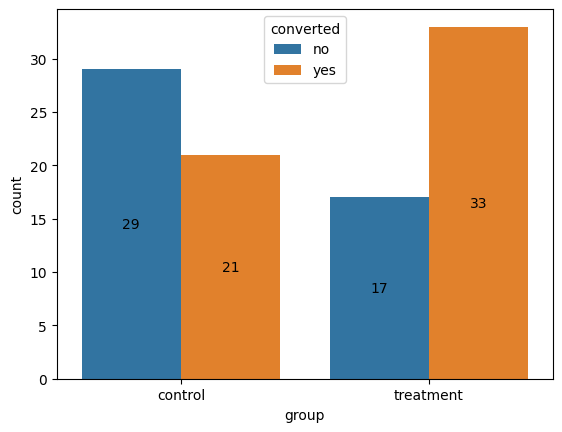

In [85]:
# Count of users that converted across all groups:
print(str(df['converted'].value_counts()))
# Countplot showing conversion by group:
ax = sns.countplot(data = df, x = 'group', hue='converted');
for container in ax.containers:
    ax.bar_label(container,label_type='center')
plt.show()

**Observations on Conversion:**
*   The control group conversion rate is 42%
*   The treatment group conversion rate is 66%

####**Univariate on Preferred Language:**

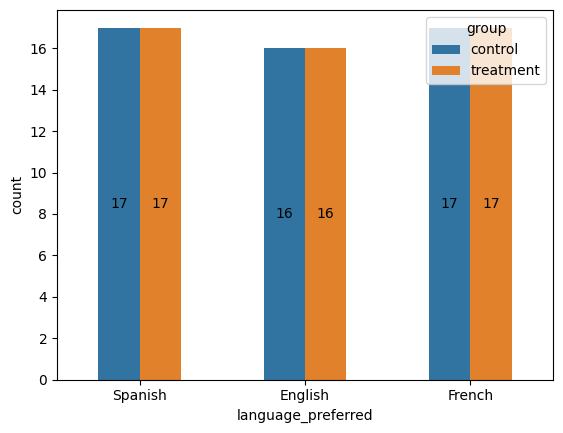

In [86]:
# Countplot showing preferred language by group:
ax = sns.countplot(data = df, x = 'language_preferred', hue='group', width=0.5);
for container in ax.containers:
    ax.bar_label(container,label_type='center')
plt.show()

**Observations on Preferred Language:**

*   Amongst the three languages, it's fairly distributed across both groups.
*   Overall, 68% of the users in the sample prefer Spanish/French
*   Overall, 32% of the users in the sample prefer English
*   Each language has an equal number of users in both the control and treatment groups



#### **Univariate on Time Spent:**

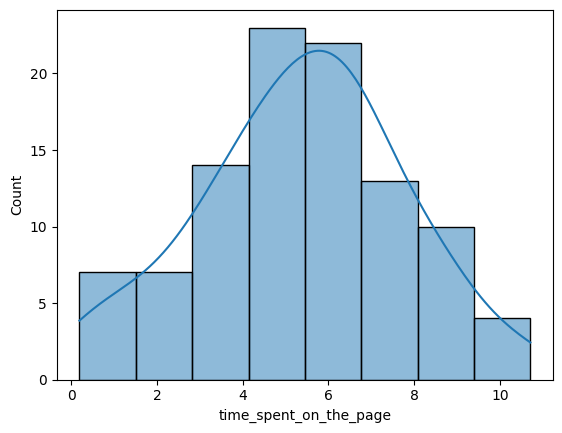

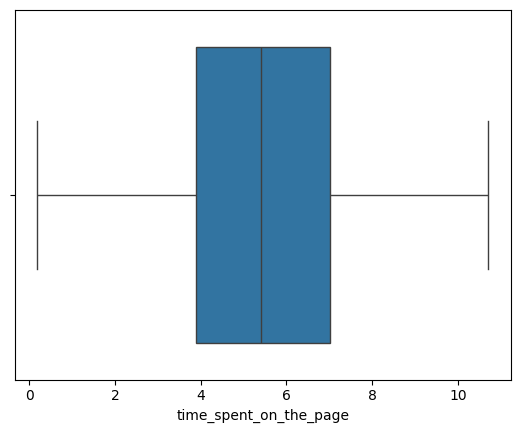

In [87]:
# Count and Box plots with time spent across both groups:
sns.histplot(data=df,x='time_spent_on_the_page',kde="true")
plt.show()
sns.boxplot(data=df,x='time_spent_on_the_page')
plt.show()


**Observations on Time Spent:**

*   Regardless of which landing page, most users spend between 5 and 6 minutes.  
*   75% of all the users (regardless of landing page) spend up to ~7 minutes.

### **Bivariate Analysis**

####**Time Spent and Group**

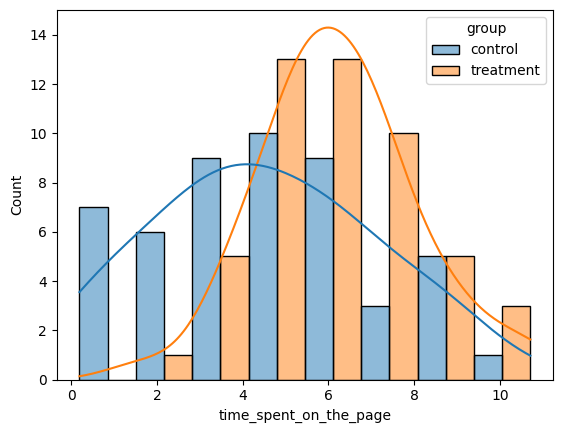

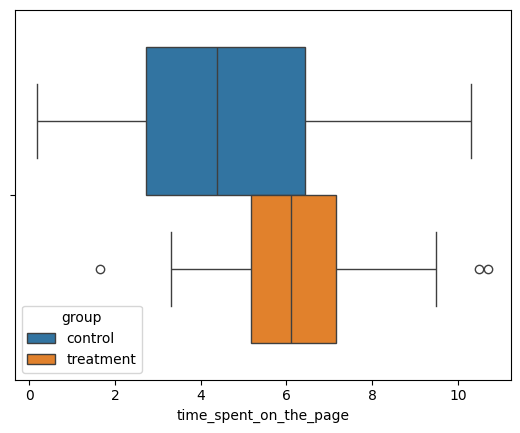

In [88]:
# Hist and Box plots showing time spent on the page as categorized by group:
sns.histplot(data=df,x='time_spent_on_the_page', hue='group', multiple='dodge', kde="true")
plt.show()
sns.boxplot(data=df,x='time_spent_on_the_page', hue='group')
plt.show()

**Observations on Time Spent and Group:**

Control Group:
*   75% of the control group users spend less than 7 minutes on the original landing page, with most hovering a little over 4 minutes, as demonstrated by the right-skew.

Treatment Group:
*   75% of the treatment group spend a little over 7 minutes on the new landing page, with most hovering around 6 minutes.
*   The treatment group has outliers on both ends, which indicates some more variability.

#### **Time Spent and Conversion, by Group**

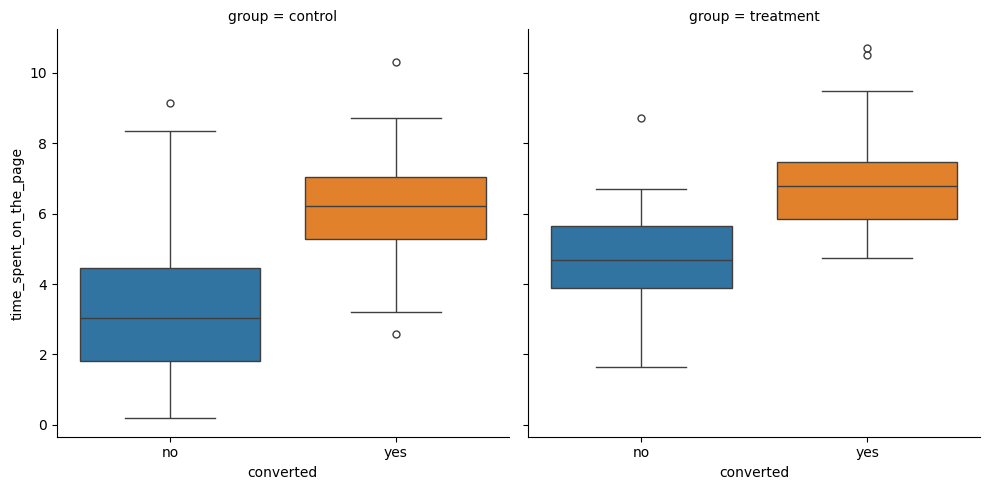

min    max      mean
group     converted                       
control   no         0.19   9.15  3.349310
          yes        2.58  10.30  6.166190
treatment no         1.65   8.73  4.882353
          yes        4.75  10.71  6.913939

In [89]:
# Catplot showing comparisons of time spent and conversion by group:
sns.catplot(data=df, x="converted", y="time_spent_on_the_page", hue='converted', col="group", kind='box');
plt.show()

# Min, Max, and Mean values for those that converted in each group:
df.groupby(['group','converted'])['time_spent_on_the_page'].agg(['min','max','mean'])

**Observations on Time Spent and Conversion:**

Control Group:
*   The median time users that converted in the control group is ~ 6 minutes as opposed to ~3 minutes for those that did not subscribe (convert).
*   As noted before, the conversion rate for the control group is 42%.

Treatment Group:
*   The median time users that converted in the treatment group is ~7 minutes, as opposed to ~5 minutes for those that did not subscribe.
*   As noted before the conversion rate for the treatment group is 66%.

#### **Time Spent and Preferred Language by Group**

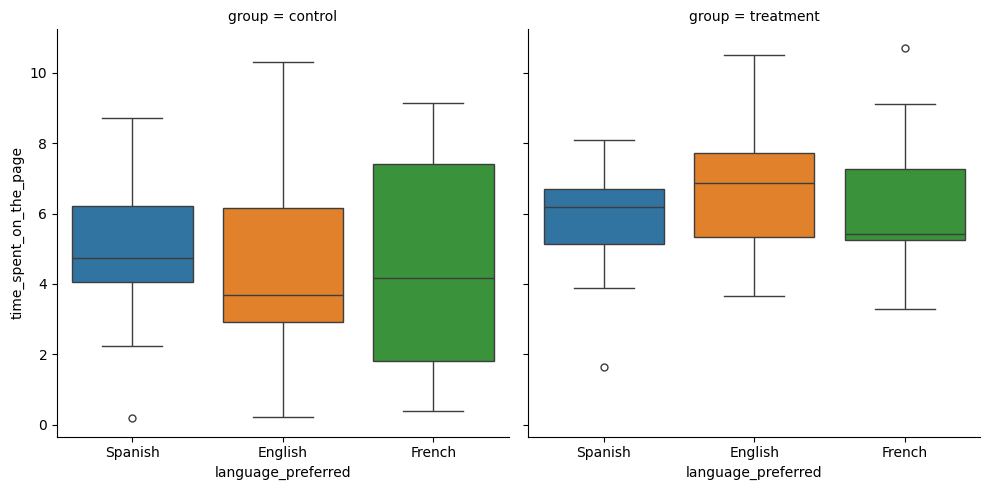

min    max      mean
group     language_preferred                       
control   English             0.22  10.30  4.454375
          French              0.40   9.15  4.310000
          Spanish             0.19   8.72  4.828235
treatment English             3.65  10.50  6.663750
          French              3.30  10.71  6.196471
          Spanish             1.65   8.08  5.835294

In [90]:
# Catplot showing comparisons of time spent and preferred language by group:
sns.catplot(data=df, x="language_preferred", y="time_spent_on_the_page", hue='language_preferred', col="group", kind='box');
plt.show()
print("\n")
# Min, Max and Mean values for languages in each group:
df.groupby(['group','language_preferred'])['time_spent_on_the_page'].agg(['min','max','mean'])

**Observations on Time Spent and Preferred Language:**

Control Group:
*   The range of time spent across all languages was ~20 seconds to just over 10 minutes, with the English language showing the widest spread.
*   Spanish -- 75% of these users spent up to a little over 6 minutes, with a median and mean hovering close to 5 minutes, and none more than ~9 minutes.
*   English -- 75% of these users spent up to ~6 minutes, and is the most right-skewed of the three languages, with the median time hovering under 4 minutes and mean at ~4.5 minutes, with some users spending a little over 10 minutes.
*   French -- 75% spent up to ~7 minutes with a median and mean a little over 4 minutes.

Treatment Group:
*   The overall range of time spent tightened across all users on the new landing page, with the minimum time spent raised to 1.7 minutes and the maximum time at ~10.7 minutes for French users.  
*   Spanish -- the median and mean hovered ~6 minutes.
*   English -- the median and mean hovered ~7 minutes.
*   French -- the median time raised to a little over 5 minutes, with a mean ~6 minutes.







### Set global alpha value as defined by problem statement

In [91]:
# Set global alpha variable
alpha = 0.05

### Define p-value Function to be used for all later alpha comparison checks

In [92]:
# Function to be used for all p-value null hypothesis comparisons
#   inputs alpha (level of significance) and the p-value and returns
#   whether to go with null or alternative.

def pvalue_compare(alpha,pvalue):
  print("alpha is", alpha)
  print("pvalue is", pvalue)
  if pvalue < alpha:
    print(f'As the p-value {pvalue} is less than the level of significance, we reject the null hypothesis.')
  else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

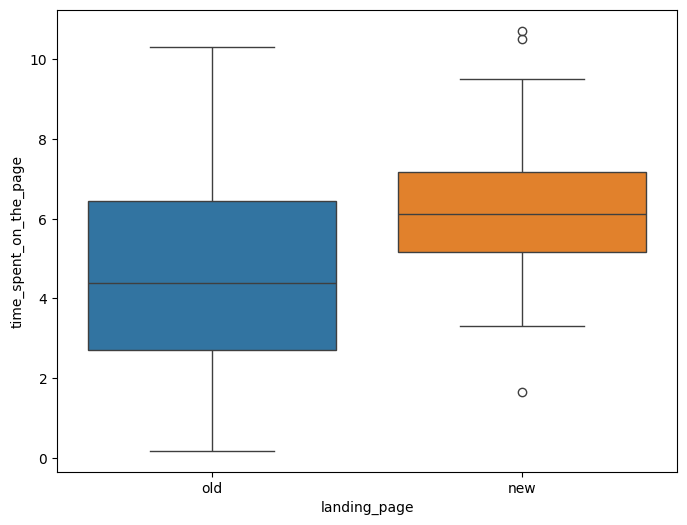

,min,max,median,mean
landing_page,,,,
new,1.65,10.71,6.105,6.2232
old,0.19,10.30,4.380,4.5324


In [93]:
# visual analysis of the time spent on the new page and the time spent on the old page
plt.figure(figsize=(8,6))
sns.boxplot(x = 'landing_page', y = 'time_spent_on_the_page', data = df, hue='landing_page')
plt.show()

print("\n")
# Min, Max, Median and Mean time spent by group:
df.groupby('landing_page')['time_spent_on_the_page'].agg(['min','max','median','mean'])

*   The median time increased by just under 2 minutes on the new landing page and the inner-quartile range is smaller, hovering between 5-7 minutes.
*   Ignoring outliers, the maximum time spent on the new page appears to be less than on the new page, however.

### Step 1: Define the null and alternate hypotheses

Let μ1 be the mean time spent for the new landing page and μ2 be the mean time spent for the old landing page.

$H_0$:  μ1 = μ2

$H_a$:  μ1 > μ2

### Step 2: Select Appropriate test

This is a one-tailed test concerning two population means from two independent populations. The population standard deviations are unknown.  A two-sample T-test is designed for this scenario.  

Assumptions:
*   Continuous data - Yes, the usage time is measured on a continuous scale.
*   Normally distributed populations - Yes, we see the sample populations to be reasonably normal, and the Central Limit Theorem applies.
*   Independent populations - Yes, the two samples are from two independent populations.
*   Random sampling from the population - Yes, we are informed that both samples are random.

We need to determine if the standard deviations from both samples are relatively the same or different.

### Step 3: Decide the significance level

As given in the problem statement, we select α = 0.05.

### Step 4: Collect and prepare data

In [94]:
# find the sample means and sample standard deviations for the two samples:

cgmean = df[df['group'] == 'control']['time_spent_on_the_page'].mean()
tgmean = df[df['group'] == 'treatment']['time_spent_on_the_page'].mean()
cgstd = df[df['group'] == 'control']['time_spent_on_the_page'].std()
tgstd = df[df['group'] == 'treatment']['time_spent_on_the_page'].std()
# calculate ratio of cgstd and tgstd:
std_ratio = cgstd/tgstd
print('Control Group Mean: ', cgmean)
print('Treatment Group Mean: ', tgmean)
print('Control Group Standard Deviation: ', cgstd)
print('Treatment Group Standard Deviation: ', tgstd)
print('Ratio of Standard Deviations: ', std_ratio)

Control Group Mean:  4.532400000000001
Treatment Group Mean:  6.2232
Control Group Standard Deviation:  2.581974849306046
Treatment Group Standard Deviation:  1.8170310387878263
Ratio of Standard Deviations:  1.4209855496076322


### Step 5: Calculate the p-value

In [95]:
from scipy.stats import ttest_ind

# find the p-value (treatment group first — order matters for one-tailed test):
test_stat, p_value = ttest_ind(
    df[df['group'] == 'treatment']['time_spent_on_the_page'],
    df[df['group'] == 'control']['time_spent_on_the_page'],
    equal_var=False,
    alternative='greater'
)
print('The p-value when std dev assumed not equal is ' + str(p_value))

The p-value when std dev assumed not equal is 0.0001392381225166549


### Step 6: Compare the p-value with $\alpha$

In [96]:
# print the conclusion based on p-value, which is basically the same regardless of equal/not equal std devs.
pvalue_compare(alpha,p_value)

alpha is 0.05
pvalue is 0.0001392381225166549
As the p-value 0.0001392381225166549 is less than the level of significance, we reject the null hypothesis.


### Step 7:  Draw inference

Since the p-value is much less than the 5% significance level, we reject the null hypothesis. Hence, we do have enough statistical evidence to say that users spend more time on the new landing page.

**A similar approach can be followed to answer the other questions.**

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

### Perform Visual Analysis

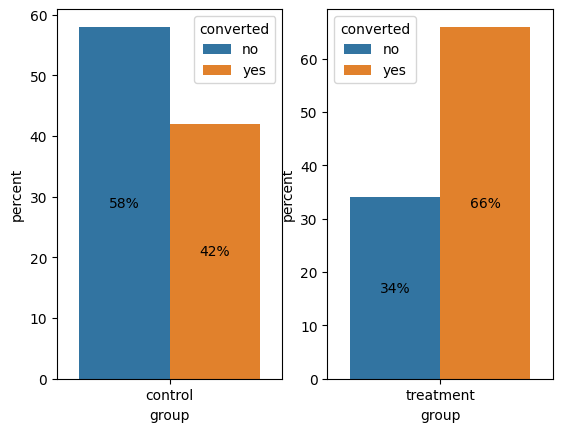

In [97]:
# Show percentages of users that convert by group:
dfcg = df[df['group'] == 'control']
dftg = df[df['group'] == 'treatment']

fig, ax =plt.subplots(1,2)
sns.countplot(data = dfcg, x = 'group', hue='converted', stat='percent', hue_order = ['no','yes'], ax=ax[0])
sns.countplot(data = dftg, x = 'group', hue='converted', stat='percent', hue_order = ['no','yes'], ax=ax[1])
# Iterate over each axes in the NumPy array
for a in ax:
  # Access the containers of each axes and add bar labels
  for container in a.containers:
    a.bar_label(container, fmt='%.0f%%', label_type='center')
fig.show()

As noted before, the percentage of conversion for the control group is 42% and 66% for the treatment group.

### Step 1: Define the null and alternate hypotheses

Let μ1 be the proportion of converted users on the new landing page and μ2 be the proportion of converted users for the old landing page.

$H_0$:  μ1 = μ2

$H_a$:  μ1 > μ2

### Step 2: Select Appropriate test

This is a one-tailed test concerning two population proportions from two independent populations.  The two proportions z test is designed for this scenario.

Assumptions:


*   Binomally distributed population - Yes, a user either converts (subscribes) or doesn't.
*   Random sampling from the population - Yes, we are informed that the collected sample is a simple random sample.


*   Can the binomial distribution approximated to normal distribution - np and n(1-p) must be greater than or equal to 10.

In [98]:
# Confirm Binomial Distribution can be approximated to a normal distribution in each sample group:
n=50
cgcount = dfcg[dfcg['converted'] == 'yes'].shape[0]
tgcount = dftg[dftg['converted'] == 'yes'].shape[0]
np1 = n*(cgcount/n)
n1p1 = n*((n-cgcount)/n)
np2 = n*(tgcount/n)
n1p2 = n*((n-tgcount)/n)

# initializing list
test_list = [np1, n1p1, np2, n1p2]

# printing np and n(1-p) values
print("List of values: " + str(test_list))

# Check if all elements in are >= 10 using all()
res = all(ele >= 10 for ele in test_list)

# Print result
print("Are all elements greater or equal to 10 ? : " + str(res))

List of values: [21.0, 28.999999999999996, 33.0, 17.0]
Are all elements greater or equal to 10 ? : True


Yes, the binomial distribution can be approximated to a normal distribution for both samples.

### Step 3: Decide the significance level

As given in the problem statement, we select α = 0.05.

### Step 4: Calculate the p-value

In [99]:
# import the required fuction
from statsmodels.stats.proportion import proportions_ztest

# set array of conversion counts
counts = np.array([tgcount, cgcount])

# set the sample sizes
nobs = np.array([50, 50])

# find the p-value
test_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')
print('The p-value is ' + str(p_value))

The p-value is 0.008026308204056278


### Step 5: Compare the p-value with $\alpha$

In [100]:
# print the conclusion based on p-value
pvalue_compare(alpha,p_value)

alpha is 0.05
pvalue is 0.008026308204056278
As the p-value 0.008026308204056278 is less than the level of significance, we reject the null hypothesis.


### Step 6:  Draw inference

Since the p-value is less than the 5% significance level, we reject the null hypothesis. Hence, we *do* have enough statistical evidence to say that the conversion rate (the proportion of users who visit the landing page and get converted) for the new page is greater than the conversion rate for the old page.

## 3. Are conversion and preferred language  independent or related?

### Perform Visual Analysis

language_preferred,English,French,Spanish
converted,,,
no,0.11,0.19,0.16
yes,0.21,0.15,0.18


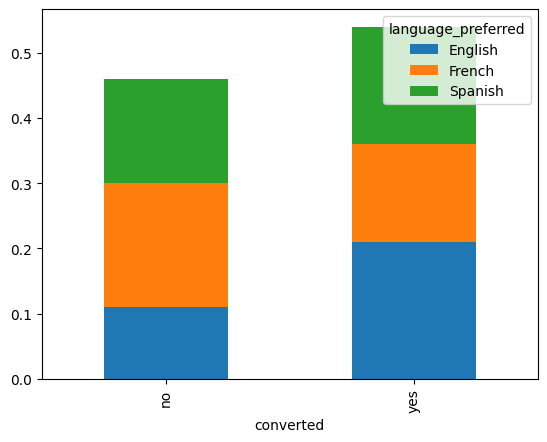

In [101]:
# Stacked bar chart using a contingency table for converted and language_preferred variables:
#pd.crosstab(df.converted,df.language_preferred,normalize=True).plot(kind='bar',stacked=True)
contingency_table = pd.crosstab(df.converted,df.language_preferred,normalize=True)
contingency_table.plot(kind='bar',stacked=True)
contingency_table

The proportion of English language users that subscribe is higher than the Spanish or French language users.

### Step 1: Define the null and alternate hypotheses

H0:  Preferred language and conversion are independent of each other

Ha: Preferred language and conversion are dependent on each other

### Step 2: Select Appropriate test

This is a test of indepdence concerning two categorical variables.  The Chi-Square Test for Independence is designed for this type of scenario.

Assumptions:
* Categorical variables - Yes, preferred language and conversion are categorical variables
* Random sampling from the population - Yes, we are informed that the collected sample is a simple random sample.  
* Expected value of the number of sample observations in each level of the variable is at least 5 - Yes, the number of observations in each level is greater than 5.

### Step 3: Decide the significance level

As given in the problem statement, we select α = 0.05.

### Step 4: Calculate the p-value

In [102]:
# import the required function
from scipy.stats import chi2_contingency

contingency_table_counts = pd.crosstab(df.converted, df.language_preferred)

chi, p_value, dof, expected = chi2_contingency(contingency_table_counts)
print('The p-value is', p_value)

The p-value is 0.21298887487543447


### Step 5: Compare the p-value with $\alpha$

In [103]:
# print the conclusion based on p-value
pvalue_compare(alpha,p_value)

alpha is 0.05
pvalue is 0.21298887487543447
As the p-value 0.21298887487543447 is greater than the level of significance, we fail to reject the null hypothesis.


### Step 6:  Draw inference

Since the p-value is greater than the 5% significance level, we fail to reject the null hypothesis.  Hence, we do *not* have enough statistical evidence to say that preferred language and conversion are dependent on each other.



## 4. Is the time spent on the new page same for the different language users?

### Perform Visual Analysis

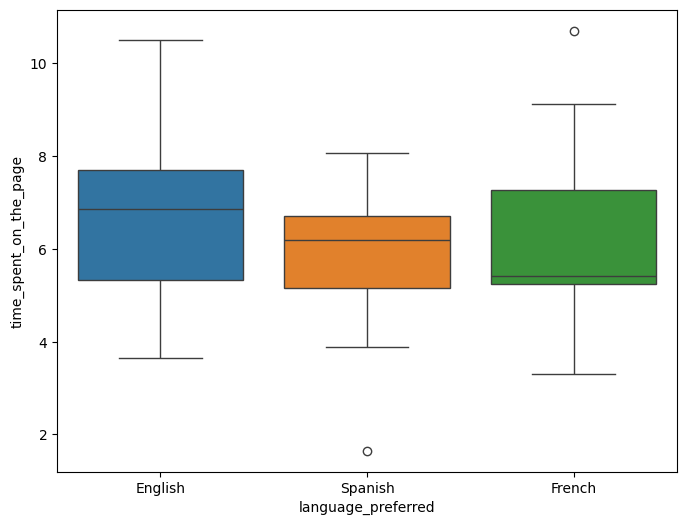

,time_spent_on_the_page
language_preferred,
English,6.663750
French,6.196471
Spanish,5.835294


In [104]:
# create a dataframe for the treatment group users:
df_treatment = df[df['group'] == 'treatment']

# plot time spent on the new page by preferred language:
plt.figure(figsize=(8,6))
sns.boxplot(x = 'language_preferred', y = 'time_spent_on_the_page', data = df_treatment, hue='language_preferred')
plt.show()

# mean time spent by language preferred:
df_treatment.groupby('language_preferred')['time_spent_on_the_page'].mean()

*   Time spent for English language users can range up to a little over 10 minutes, with a mean of 6.7 minutes.
*   Time spent for French users cap at ~9 minutes with a mean of 6.2 minutes.
*   Time spent for Spanish users caps at ~8 with a mean of 5.8 minutes.






### Step 1: Define the null and alternate hypotheses

Let  μ1,μ2,μ3 be the means time spent on the new page by preferred language, English, Spanish and French, respectively.

H0:μ1=μ2=μ3

Ha:  At least one of the mean times is different from the rest.

### Step 2: Select Appropriate test

This is related to comparison of 3 population means.  The one-way ANOVA test is designed for determining equality amongst more than two populations.

Assumptions:
*   The populations are normally distributed -- to be confirmed using Shapiro-Wilk's test
*   Population variances are equal -- to be determined by Levene's test
*   Samples are random and independent -- Yes, we are informed they are random and independent.

### Step 3: Decide the significance level

As given in the problem statement, we select α = 0.05.

### Step 4: Confirm normal distribution using Shapiro-Wilk's test

H0:  Time spent on the new page follows a normal distribution

Ha: Time spent on the new page does not follow a normal distribution

In [105]:
# Assumption 1: Normality

# find the p-value using Shapiro-Wilk's test:
w, p_value = stats.shapiro(df_treatment['time_spent_on_the_page'])

# print the conclusion based on p-value
pvalue_compare(alpha,p_value)

alpha is 0.05
pvalue is 0.8040040364746845
As the p-value 0.8040040364746845 is greater than the level of significance, we fail to reject the null hypothesis.


Since the p-value of the Shapiro-Wilk's test is greater than the 5% significance level, we fail to reject the null hypothesis that that the time spent on the new page follows a normal distribution.

### Step 5: Confirm population variances are equal using Levene's test

H0:  All population variances are equal

Ha: At least one variance is different from the rest.

In [106]:
# Assumption 2: Homogeneity of Variance

# import the required function
from scipy.stats import levene

# find the p-value using Levene's test:
statistic, p_value = levene( df_treatment['time_spent_on_the_page'][df_treatment['language_preferred']=="English"],
                                   df_treatment['time_spent_on_the_page'][df_treatment['language_preferred']=="Spanish"],
                                   df_treatment['time_spent_on_the_page'][df_treatment['language_preferred']=="French"])
# print the conclusion based on p-value
pvalue_compare(alpha,p_value)

alpha is 0.05
pvalue is 0.46711357711340173
As the p-value 0.46711357711340173 is greater than the level of significance, we fail to reject the null hypothesis.


Since the p-value of the Levene's test is greater than the 5% significance level, we fail to reject the null hypothesis that all the variations are equal.

### Step 6: Calculate the p-value

In [107]:
#import the required function
from scipy.stats import f_oneway

# perform one-way anova test
test_stat, p_value = f_oneway(df_treatment['time_spent_on_the_page'][df_treatment['language_preferred']=="English"],
                                   df_treatment['time_spent_on_the_page'][df_treatment['language_preferred']=="Spanish"],
                                   df_treatment['time_spent_on_the_page'][df_treatment['language_preferred']=="French"])
print('The p-value is ' + str(p_value))

The p-value is 0.43204138694325955


### Step 5: Compare the p-value with $\alpha$

In [108]:
# print the conclusion based on p-value
pvalue_compare(alpha,p_value)

alpha is 0.05
pvalue is 0.43204138694325955
As the p-value 0.43204138694325955 is greater than the level of significance, we fail to reject the null hypothesis.


### Step 6:  Draw inference

Since the p-value is greater than the 5% significance level, we fail to reject the null hypothesis. Hence, we do not have enough statistical evidence to say that the mean time spent on the new page is different among the English, Spanish and French language user groups.  

As the question is if the time spent is *the same* across the different preferred language groups, the answer is yes.

## Conclusion and Business Recommendations

### In answer to the posed questions:

1.   Do users spend more time on the new landing page?

    Answer:  **Yes**.  There is enough statistical evidence to say that users spend more time on the new landing page.

2.   Is the conversion rate higher on the new landing page?

    Answer:  **Yes**.  There is enough statistical evidence to confirm that the conversion rate (the proportion of users who visit the landing page and get converted) for the new page is greater than the conversion rate for the old page.

3.   Does preferred language play a factor in conversion rate?

    Answer:  **No**, preferred language is not statistically shown to play a factor in conversion rate.

4.   Is the mean time spent on the new landing page the same for different preferred language users?

    Answer:  **Yes**. The mean time spent on the new landing page does is not statistically shown to differ amongst the English, Spanish, and French preferred language users, and therefore is shown to be the same.

### Business Recommendations:

We recommend proceeding with using the new landing page and continuing with the design direction associated with the new outline, navigation, and content.

To draw more associations with subscribing users and inform the type of content to expand or improve, it would be fruitful to pull more detailed data on the specific content these users are spending the most time consuming, such as:

*   Text or Video format
*   News category (World, Nation, Local, Politics, Weather, Human Interest, Sports, Entertainment etc.)
*   Length of the article/video
*   Writing style/video presentation of the article (inverted pyramid, delayed, descriptive, suspense lead etc.)
*   Age, education, location and other demographic information related to subscribing users
*   Computing device used
*   Time of day or day of week

### Other recommendations for increasing conversion/subscribership:
*   Offer quality, exclusive content teased from the landing page (beyond standard newswire fare)
*   Offer discount promotions on subscriptions for first-time subscribers, or through a friends/family program
*   Feature quality, reputable journalists that cite reputable sources and leverage expert analysis
*   Focus on a specific area to distinguish ENews Express as an authority or preferred news source, whether it be focus on a excelling on specific news converage, or for style of presenting information in an easily consumed format.
*   People love puzzles -- offer exclusive, novel puzzles with intellectual interest or to test current events knowledge that encourages specific ENews Express readership and engagement.











___